# Human Resources Analysis

This project uses a Human Resources data set from Kaggle (https://www.kaggle.com/datasets/rhuebner/human-resources-data-set/data?select=HRDataset_v14.csv) to explore, visualize, and glean insights including how employees' performance and engagement-related data can potentially affect retention.

---

## 1) Import the necessary Python packages

Import the necessary Python packages in order to use their functions to analyze the data set.

In [1]:
import pandas as pd
import numpy as np
import statistics as st
from datetime import datetime as dt
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
import seaborn as sns
sns.set()

## 2) Load the data

Load the csv file into Jupyter Notebook in order to analyze it.

In [2]:
hr = pd.read_csv('HRdataset_v14.csv')
hr

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


## 3) Explore the data set's structure

Confirm the data set's total number of rows, excluding the heading row.

In [3]:
len(hr)

311

Confirm the data set's data type info.

In [4]:
hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

Confirm if there are any null values within the data set. We see that under the "DateofTermination" field, there are 207 null values, which implies that there are 207 active employees, and thus 104 terminated employees.

In [5]:
hr.isnull().sum()

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

Confirm that there are no duplicate Employee IDs, and thus, employee records. We see that the number of unique Employee IDs match the total number of rows in the data set, and thus there are no duplicates.

In [6]:
len(hr.EmpID.unique())

311

## 4) Explore the data set

We can generate a statistical summary of the data set's numerical values.

The following are of note.

#### Engagement Survey Scores (From 1 - 5):

The average score is 4.11 with a standard deviation of 0.79.


#### Employee Satisfaction Scores (From 1 - 5):

The average is 3.89 with a standard deviation of 0.90.

#### Special Projects Count:

The average is 1.21 with a standard deviation of 2.39.

#### Days Late

The average is 0.41 with a standard deviation of 1.29.


#### Absences:

The average number of days employees are absent is 10.23, with a standard deviation of 5.85 days. There is a wide variation in the number of absences for employees.

In [7]:
hr.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


Generate a list of the individual states employees work in within the data set.

In [8]:
list(sorted(hr['State'].unique()))

['AL',
 'AZ',
 'CA',
 'CO',
 'CT',
 'FL',
 'GA',
 'ID',
 'IN',
 'KY',
 'MA',
 'ME',
 'MT',
 'NC',
 'ND',
 'NH',
 'NV',
 'NY',
 'OH',
 'OR',
 'PA',
 'RI',
 'TN',
 'TX',
 'UT',
 'VA',
 'VT',
 'WA']

Generate a list of individual recruitment sources in alphabetical order within the data set.

In [9]:
list(sorted(hr['RecruitmentSource'].unique()))

['CareerBuilder',
 'Diversity Job Fair',
 'Employee Referral',
 'Google Search',
 'Indeed',
 'LinkedIn',
 'On-line Web application',
 'Other',
 'Website']

Generate a list of individual departments in alphabetical order within the data set.

In [10]:
list(sorted(hr['Department'].unique()))

['Admin Offices',
 'Executive Office',
 'IT/IS',
 'Production       ',
 'Sales',
 'Software Engineering']

Generate a list of the individual job titles in alphabetical order within the data set.

In [11]:
list(sorted(hr['Position'].unique()))

['Accountant I',
 'Administrative Assistant',
 'Area Sales Manager',
 'BI Developer',
 'BI Director',
 'CIO',
 'Data Analyst',
 'Data Analyst ',
 'Data Architect',
 'Database Administrator',
 'Director of Operations',
 'Director of Sales',
 'Enterprise Architect',
 'IT Director',
 'IT Manager - DB',
 'IT Manager - Infra',
 'IT Manager - Support',
 'IT Support',
 'Network Engineer',
 'President & CEO',
 'Principal Data Architect',
 'Production Manager',
 'Production Technician I',
 'Production Technician II',
 'Sales Manager',
 'Senior BI Developer',
 'Shared Services Manager',
 'Software Engineer',
 'Software Engineering Manager',
 'Sr. Accountant',
 'Sr. DBA',
 'Sr. Network Engineer']

Generate a list of individual performance score descriptions in alphabetical order within the data set.

In [12]:
list(sorted(hr['PerformanceScore'].unique()))

['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP']

Generate a list of the individual hire dates in chronological order within the data set. We see that the earliest hire date is on January 9, 2006 and the latest hire date is on July 9, 2018.

In [13]:
list(sorted(pd.to_datetime(hr['DateofHire'].unique())))

[Timestamp('2006-01-09 00:00:00'),
 Timestamp('2007-06-25 00:00:00'),
 Timestamp('2007-11-05 00:00:00'),
 Timestamp('2008-01-07 00:00:00'),
 Timestamp('2008-09-02 00:00:00'),
 Timestamp('2008-10-27 00:00:00'),
 Timestamp('2009-01-05 00:00:00'),
 Timestamp('2009-01-08 00:00:00'),
 Timestamp('2009-04-27 00:00:00'),
 Timestamp('2009-07-06 00:00:00'),
 Timestamp('2009-10-26 00:00:00'),
 Timestamp('2010-04-10 00:00:00'),
 Timestamp('2010-04-26 00:00:00'),
 Timestamp('2010-05-01 00:00:00'),
 Timestamp('2010-07-20 00:00:00'),
 Timestamp('2010-08-30 00:00:00'),
 Timestamp('2010-09-27 00:00:00'),
 Timestamp('2010-10-25 00:00:00'),
 Timestamp('2011-01-10 00:00:00'),
 Timestamp('2011-01-21 00:00:00'),
 Timestamp('2011-02-07 00:00:00'),
 Timestamp('2011-02-21 00:00:00'),
 Timestamp('2011-03-07 00:00:00'),
 Timestamp('2011-04-04 00:00:00'),
 Timestamp('2011-04-15 00:00:00'),
 Timestamp('2011-05-02 00:00:00'),
 Timestamp('2011-05-16 00:00:00'),
 Timestamp('2011-05-31 00:00:00'),
 Timestamp('2011-06-

Confirm the number of individual hire dates within the data set.

In [14]:
len(hr['DateofHire'].unique())

101

Generate a list of the individual termination dates in within the data set. We see that there is an entry called "nan", or empty entry, for those employees who are currently active.

In [15]:
list(hr['DateofTermination'].unique())

[nan,
 '6/16/2016',
 '9/24/2012',
 '9/6/2016',
 '1/12/2017',
 '9/19/2016',
 '4/6/2017',
 '8/4/2017',
 '9/12/2015',
 '4/4/2014',
 '2/19/2016',
 '8/7/2014',
 '6/15/2013',
 '8/2/2014',
 '11/15/2015',
 '1/7/2013',
 '9/26/2011',
 '9/23/2016',
 '6/8/2016',
 '11/4/2015',
 '6/6/2017',
 '9/27/2018',
 '2/25/2018',
 '6/5/2013',
 '5/17/2016',
 '6/24/2013',
 '1/9/2013',
 '8/19/2018',
 '11/15/2016',
 '9/5/2015',
 '6/25/2015',
 '3/15/2015',
 '5/30/2011',
 '1/11/2014',
 '10/31/2014',
 '12/15/2015',
 '6/18/2013',
 '4/7/2012',
 '4/15/2015',
 '4/1/2013',
 '4/29/2018',
 '4/1/2016',
 '4/24/2014',
 '6/4/2015',
 '1/9/2014',
 '12/12/2015',
 '3/31/2014',
 '4/15/2013',
 '9/26/2018',
 '9/15/2016',
 '11/14/2015',
 '9/26/2017',
 '8/19/2012',
 '11/11/2016',
 '9/4/2014',
 '5/25/2016',
 '5/1/2018',
 '8/19/2013',
 '1/12/2014',
 '9/7/2015',
 '5/1/2016',
 '12/28/2017',
 '9/15/2015',
 '10/25/2015',
 '2/4/2013',
 '5/18/2016',
 '11/30/2012',
 '6/4/2018',
 '8/15/2015',
 '4/7/2018',
 '1/15/2016',
 '10/22/2011',
 '2/8/2012',


Confirm the number of individual termination date values within the data set. Note that this includes the "nan" value.

In [16]:
len(hr['DateofTermination'].unique())

97

We will create a variable called "TermDatesList" that will consist of only termination dates (the "nan" value will be removed).

In [17]:
TermDates = list((hr['DateofTermination'].unique()))
TermDatesList = [i for i in TermDates if str(i) != 'nan']
TermDatesList

['6/16/2016',
 '9/24/2012',
 '9/6/2016',
 '1/12/2017',
 '9/19/2016',
 '4/6/2017',
 '8/4/2017',
 '9/12/2015',
 '4/4/2014',
 '2/19/2016',
 '8/7/2014',
 '6/15/2013',
 '8/2/2014',
 '11/15/2015',
 '1/7/2013',
 '9/26/2011',
 '9/23/2016',
 '6/8/2016',
 '11/4/2015',
 '6/6/2017',
 '9/27/2018',
 '2/25/2018',
 '6/5/2013',
 '5/17/2016',
 '6/24/2013',
 '1/9/2013',
 '8/19/2018',
 '11/15/2016',
 '9/5/2015',
 '6/25/2015',
 '3/15/2015',
 '5/30/2011',
 '1/11/2014',
 '10/31/2014',
 '12/15/2015',
 '6/18/2013',
 '4/7/2012',
 '4/15/2015',
 '4/1/2013',
 '4/29/2018',
 '4/1/2016',
 '4/24/2014',
 '6/4/2015',
 '1/9/2014',
 '12/12/2015',
 '3/31/2014',
 '4/15/2013',
 '9/26/2018',
 '9/15/2016',
 '11/14/2015',
 '9/26/2017',
 '8/19/2012',
 '11/11/2016',
 '9/4/2014',
 '5/25/2016',
 '5/1/2018',
 '8/19/2013',
 '1/12/2014',
 '9/7/2015',
 '5/1/2016',
 '12/28/2017',
 '9/15/2015',
 '10/25/2015',
 '2/4/2013',
 '5/18/2016',
 '11/30/2012',
 '6/4/2018',
 '8/15/2015',
 '4/7/2018',
 '1/15/2016',
 '10/22/2011',
 '2/8/2012',
 '1/26

Confirm the number of individual termination dates without the "nan" value within the data set. We see that the number is 96, which is one less than the previous count of 97.

In [18]:
len(TermDatesList)

96

Generate a list of the individual termination dates in chronological order within the data set. We see that the earliest termination date is on August 30, 2010 and the latest termination date is on November 10, 2018.

In [19]:
ConvertedTermDatesListSorted = sorted(pd.to_datetime(TermDatesList))
ConvertedTermDatesListSorted

[Timestamp('2010-08-30 00:00:00'),
 Timestamp('2011-05-30 00:00:00'),
 Timestamp('2011-09-26 00:00:00'),
 Timestamp('2011-10-22 00:00:00'),
 Timestamp('2012-01-02 00:00:00'),
 Timestamp('2012-02-08 00:00:00'),
 Timestamp('2012-04-07 00:00:00'),
 Timestamp('2012-05-14 00:00:00'),
 Timestamp('2012-08-19 00:00:00'),
 Timestamp('2012-09-24 00:00:00'),
 Timestamp('2012-11-30 00:00:00'),
 Timestamp('2013-01-07 00:00:00'),
 Timestamp('2013-01-09 00:00:00'),
 Timestamp('2013-02-04 00:00:00'),
 Timestamp('2013-04-01 00:00:00'),
 Timestamp('2013-04-15 00:00:00'),
 Timestamp('2013-06-05 00:00:00'),
 Timestamp('2013-06-15 00:00:00'),
 Timestamp('2013-06-18 00:00:00'),
 Timestamp('2013-06-24 00:00:00'),
 Timestamp('2013-08-19 00:00:00'),
 Timestamp('2013-09-25 00:00:00'),
 Timestamp('2014-01-09 00:00:00'),
 Timestamp('2014-01-11 00:00:00'),
 Timestamp('2014-01-12 00:00:00'),
 Timestamp('2014-03-31 00:00:00'),
 Timestamp('2014-04-04 00:00:00'),
 Timestamp('2014-04-24 00:00:00'),
 Timestamp('2014-05-

Generate a list of individual termination reasons in alphabetical order within the data set.

In [20]:
list(sorted(hr['TermReason'].unique()))

['Another position',
 'Fatal attraction',
 'Learned that he is a gangster',
 'N/A-StillEmployed',
 'attendance',
 'career change',
 'gross misconduct',
 'hours',
 'maternity leave - did not return',
 'medical issues',
 'military',
 'more money',
 'no-call, no-show',
 'performance',
 'relocation out of area',
 'retiring',
 'return to school',
 'unhappy']

## 5) Clean the data set

Clean the termination reasons by capitalizing the first letter.

In [21]:
TermReason_v1 = [i.capitalize() for i in list(hr['TermReason'])]
TermReason_v1

['N/a-stillemployed',
 'Career change',
 'Hours',
 'N/a-stillemployed',
 'Return to school',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'Another position',
 'Unhappy',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'Another position',
 'Attendance',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'Performance',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'Career change',
 'Learned that he is a gangster',
 'N/a-stillemployed',
 'Retiring',
 'Another position',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'Another position',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'N/a-stillemployed',
 'Relocation out of area',
 'N/a-

Confirm the number of termination reasons after cleaning. We see that 311 matches the number of total employees.

In [22]:
len(TermReason_v1)

311

To further clean the termination reasons for readability, we will replace "N/a-stillemployed" with 'N/A - Active'.

In [23]:
TermReason_clean = ['N/A - Active' if i == 'N/a-stillemployed' else i for i in TermReason_v1]
TermReason_clean

['N/A - Active',
 'Career change',
 'Hours',
 'N/A - Active',
 'Return to school',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'Another position',
 'Unhappy',
 'N/A - Active',
 'N/A - Active',
 'Another position',
 'Attendance',
 'N/A - Active',
 'N/A - Active',
 'Performance',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'Career change',
 'Learned that he is a gangster',
 'N/A - Active',
 'Retiring',
 'Another position',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'Another position',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'Relocation out of area',
 'N/A - Active',
 'N/A - Active',
 'Unhappy',
 'Career change',
 'N/A - Active',
 'N/A - Active',
 'Performance',
 'N/A - Active',
 'N/A - Active',
 'N/A - Active',
 'N/A 

We will then update the "TermReason" column with the the cleaned termination reasons column in the hr data set. We can then confirm that the update has occurred below.

In [24]:
hr['TermReason'] = TermReason_clean
hr['TermReason']

0          N/A - Active
1         Career change
2                 Hours
3          N/A - Active
4      Return to school
             ...       
306        N/A - Active
307    Another position
308        N/A - Active
309        N/A - Active
310        N/A - Active
Name: TermReason, Length: 311, dtype: object

## 6) Data Visualizations

In this section, we will visualize specific HR data using bar charts and distribution plots.

In this visualization, we see the break down of Employment Status of employees by Active, Voluntarily Terminated, and Terminated for Cause.

Text(0.5, 1.02, 'Employment Status Bar Chart')

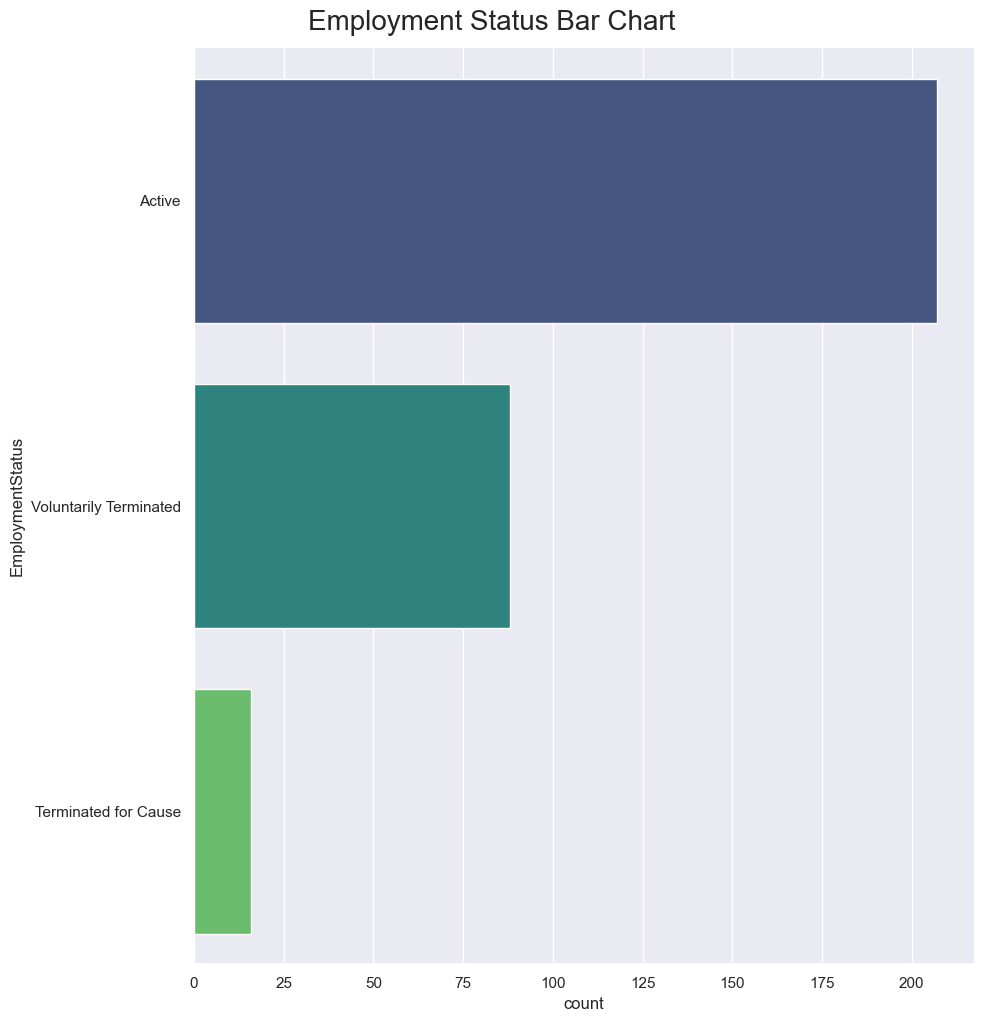

In [25]:
EmploymentStatusViz = sns.catplot(
                data = hr, y = "EmploymentStatus", height = 10, kind = "count",
                order = hr['EmploymentStatus'].value_counts().index,
                palette = "viridis",
            )
EmploymentStatusViz.fig.suptitle("Employment Status Bar Chart", fontsize = 20, y = 1.02)

In this visualization, we see the break down of how many employees are in each state. We see that most employees are located in Massachusetts.

Text(0.5, 1.02, 'Employees in States')

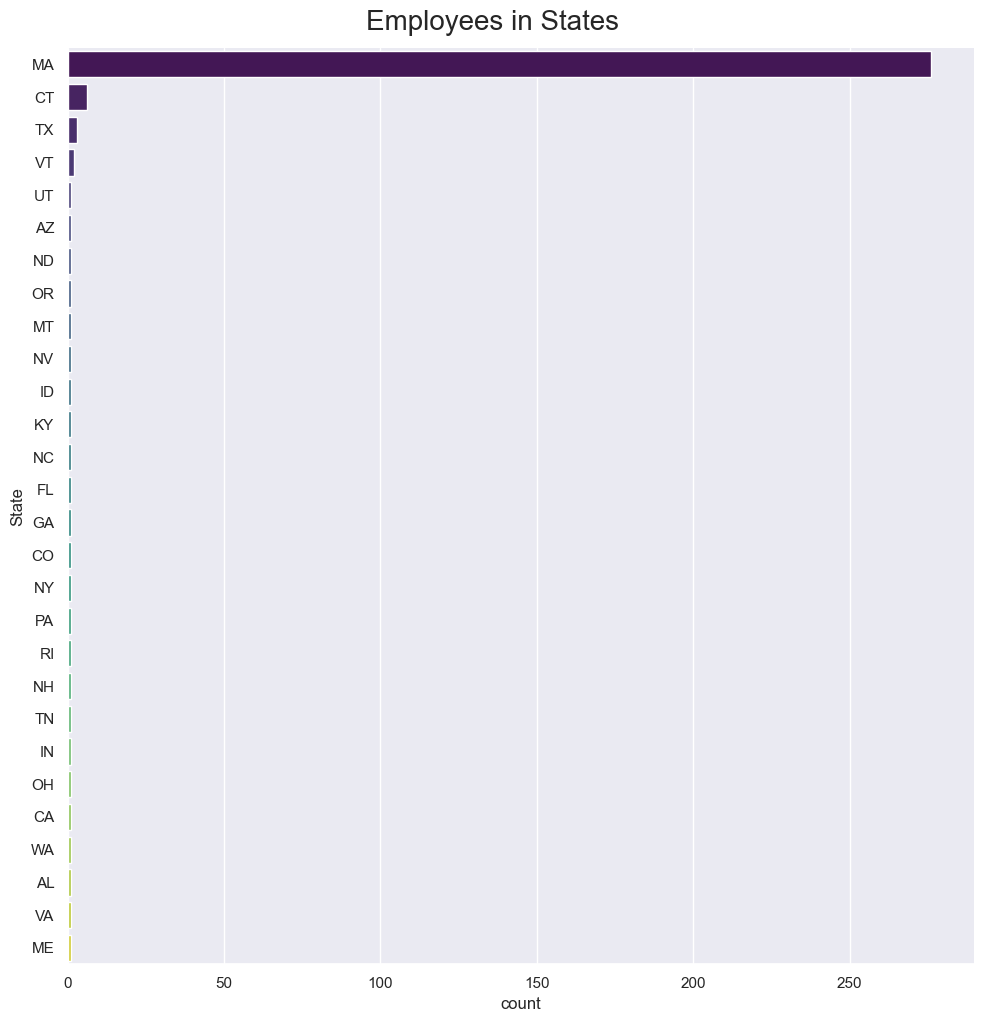

In [26]:
StateViz = sns.catplot(
                            data = hr, y = "State", height = 10, kind = "count",
                            order = hr['State'].value_counts().index,
                            palette = "viridis",
                        )
StateViz.fig.suptitle("Employees in States", fontsize = 20, y = 1.02)

In this visualization, we see the break down of recruitment sources, with most employees coming from Indeed, followed by LinkedIn and Google Search.

Text(0.5, 1.02, 'Recruitment Source Bar Chart')

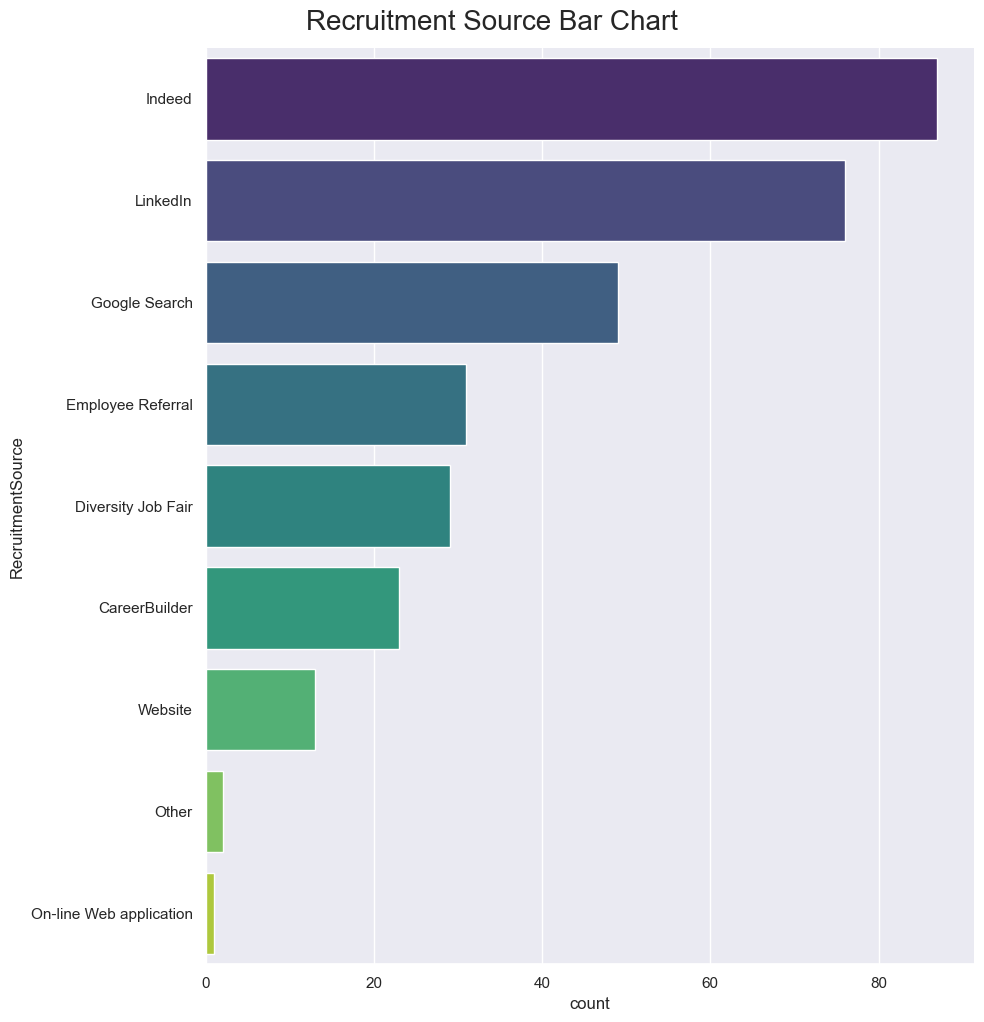

In [27]:
RecruitmentSourceViz = sns.catplot(
                            data = hr, y = "RecruitmentSource", height = 10, kind = "count",
                            order = hr['RecruitmentSource'].value_counts().index,
                            palette = "viridis",
                        )
RecruitmentSourceViz.fig.suptitle("Recruitment Source Bar Chart", fontsize = 20, y = 1.02)

In this visualization, we see the break down of how many employees are in each department. Most employees have been under the Production department.

Text(0.5, 1.02, 'Department Bar Chart')

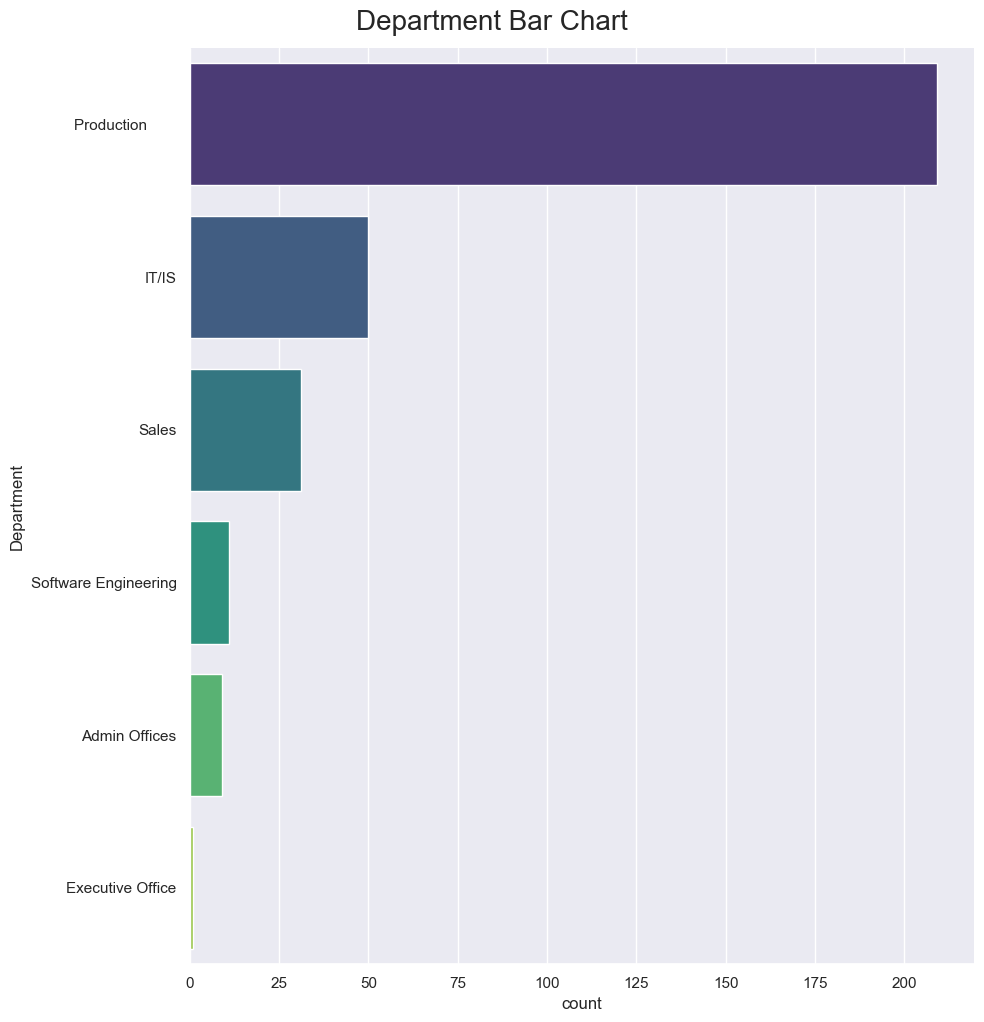

In [28]:
DepartmentViz = sns.catplot(
                    data = hr, y = "Department", height = 10, kind = "count",
                    order = hr['Department'].value_counts().index,
                    palette = "viridis",
                )
DepartmentViz.fig.suptitle("Department Bar Chart", fontsize = 20, y = 1.02)

In this visualization, we see the break down of employee job titles (Position). The organization consists of mostly Production Technicians I and II, followed by Area Sales Manager, Production Manager, and Software Engineer.

Text(0.5, 1.02, 'Position Bar Chart')

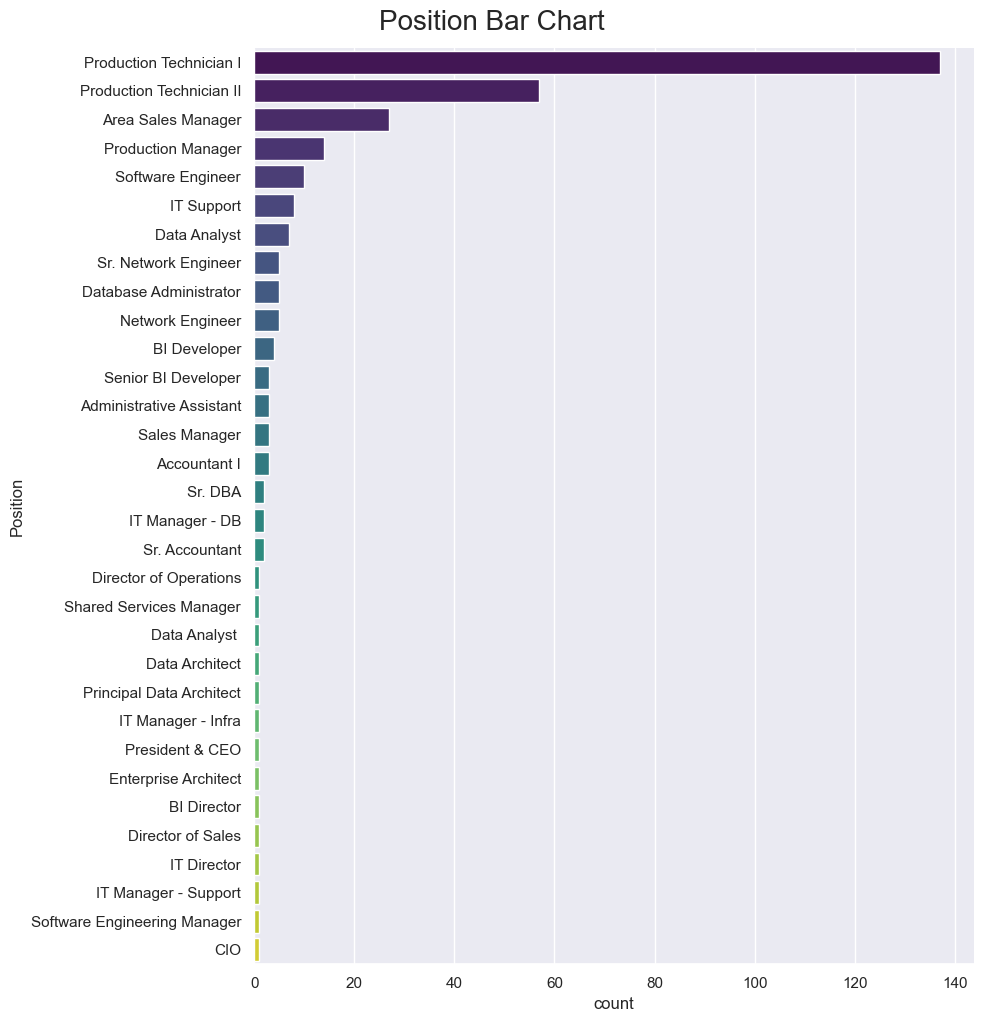

In [29]:
PositionViz = sns.catplot(
                data = hr, y = "Position", height = 10, kind = "count",
                order = hr['Position'].value_counts().index,
                palette = "viridis",
            )
PositionViz.fig.suptitle("Position Bar Chart", fontsize = 20, y = 1.02)

In this visualization, we see the break down of performance scores. Most employees fall under Fully Meets.

Text(0.5, 1.02, 'Performance Score Bar Chart')

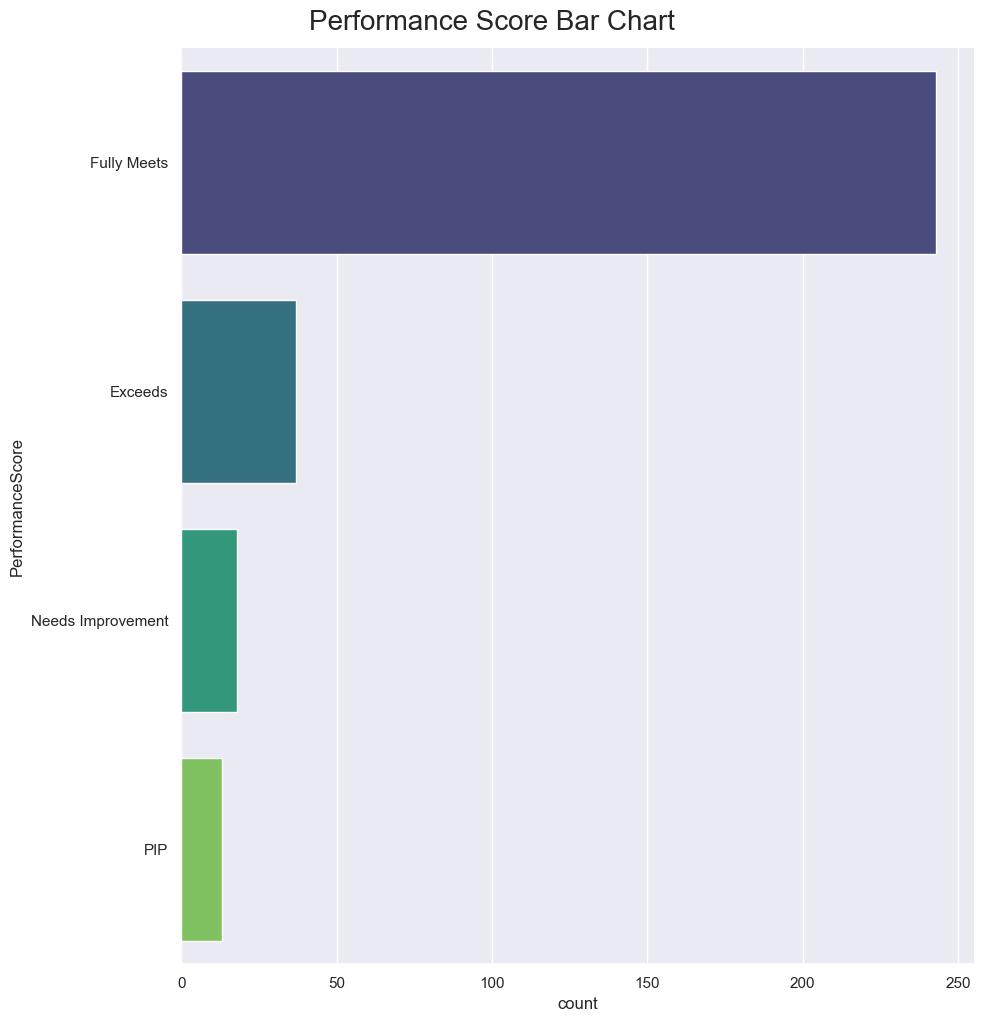

In [30]:
PerformanceScoreViz = sns.catplot(
                            data = hr, y = "PerformanceScore", height = 10, kind = "count",
                            order = hr['PerformanceScore'].value_counts().index,
                            palette = "viridis",
                        )
PerformanceScoreViz.fig.suptitle("Performance Score Bar Chart", fontsize = 20, y = 1.02)

In this visualization, we see the salary distribution of employees. Most employees fall within the \$70-75K range.

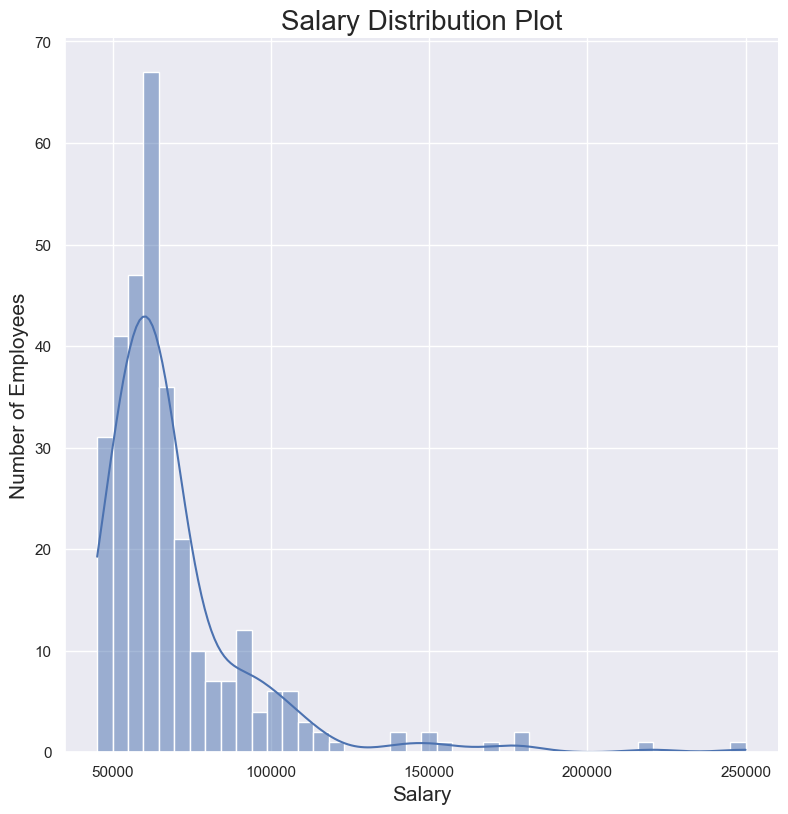

In [31]:
sns.displot(hr.Salary, height = 8, kde = True)
plt.title('Salary Distribution Plot', fontsize = 20)
plt.xlabel('Salary', fontsize = 15)
plt.ylabel('Number of Employees', fontsize = 15)
plt.xticks(rotation = 0)
plt.show()

In this visualization, we see the engagement survey scores distribution of employees. Most employees have an engagement score of 4 or higher (out of 5).

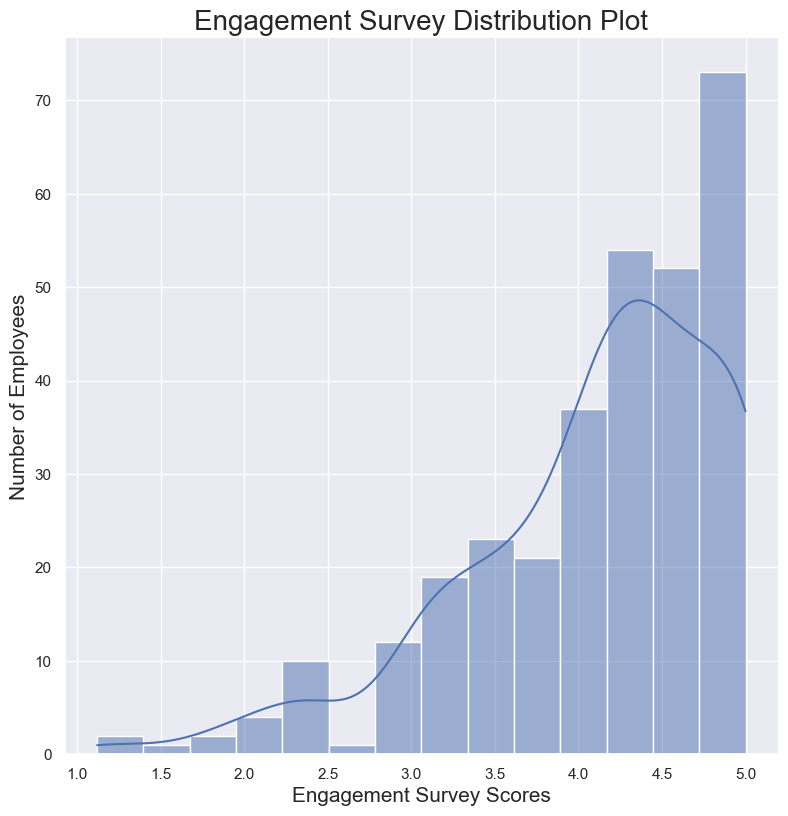

In [32]:
sns.displot(hr.EngagementSurvey, height = 8, kde = True)
plt.title('Engagement Survey Distribution Plot', fontsize = 20)
plt.xlabel('Engagement Survey Scores', fontsize = 15)
plt.ylabel('Number of Employees', fontsize = 15)
plt.xticks(rotation = 0)
plt.show()

In this visualization, we see the histogram for the employee satisfaction scores. Most employees have a satisfaction score of 3 or higher.

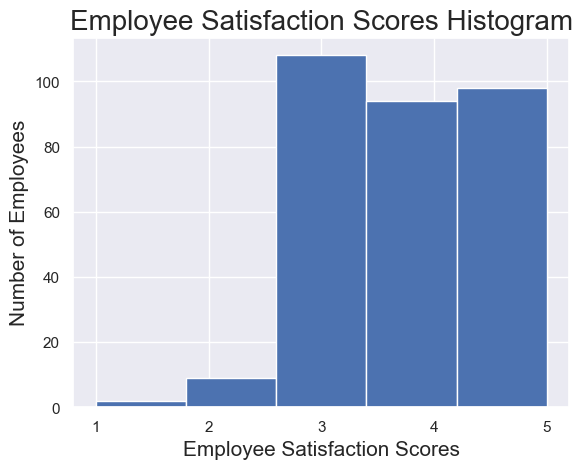

In [33]:
plt.hist(hr.EmpSatisfaction, bins = 5, align = "mid")
plt.xticks(ticks = [1, 2, 3, 4, 5])
plt.title("Employee Satisfaction Scores Histogram", fontsize = 20)
plt.xlabel("Employee Satisfaction Scores", fontsize = 15)
plt.ylabel("Number of Employees", fontsize = 15)
plt.show()

In this visualization, we see the special projects distribution. For those that have completed special projects, most have done 5 or 6 of them.

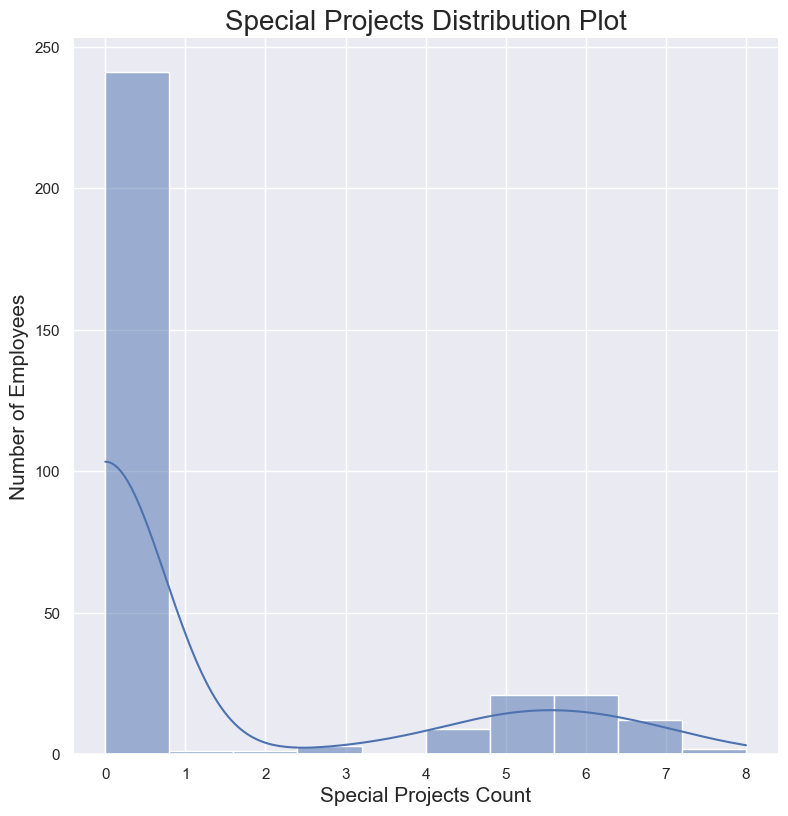

In [34]:
sns.displot(hr.SpecialProjectsCount, height = 8, kde = True)
plt.title('Special Projects Distribution Plot', fontsize = 20)
plt.xlabel('Special Projects Count', fontsize = 15)
plt.ylabel('Number of Employees', fontsize = 15)
plt.xticks(rotation = 0)
plt.show()

In this visualization, we see the distribution of how many days employees have been late. For those that have been late, most have been late 4 days.

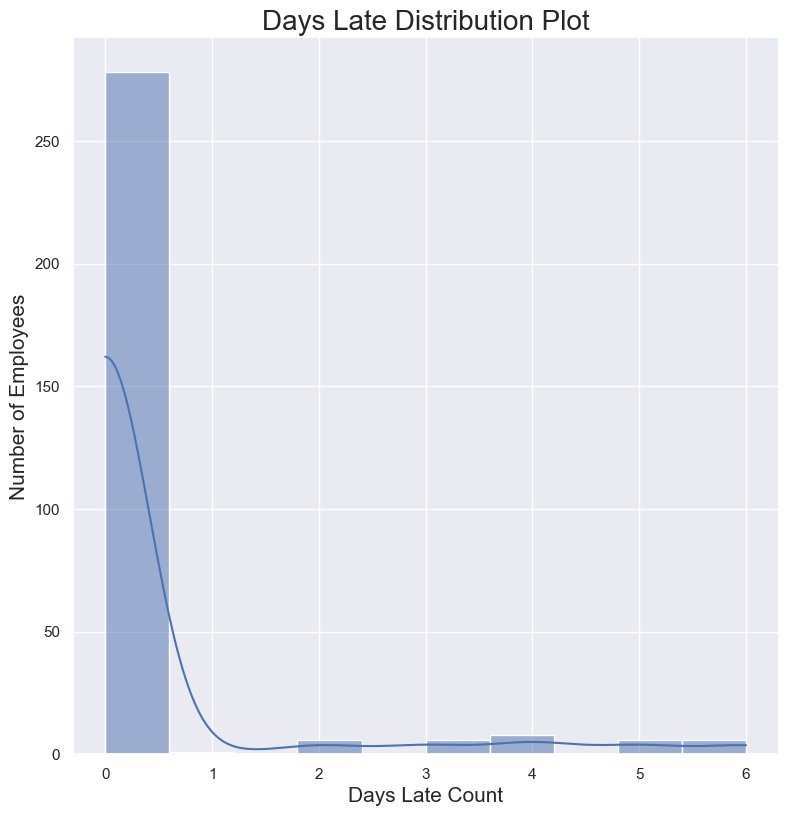

In [35]:
sns.displot(hr.DaysLateLast30, height = 8, kde = True)
plt.title('Days Late Distribution Plot', fontsize = 20)
plt.xlabel('Days Late Count', fontsize = 15)
plt.ylabel('Number of Employees', fontsize = 15)
plt.xticks(rotation = 0)
plt.show()

In this visualization, we see the days absent distribution of employees. The number of days employees were absent varies and there are no clear patterns.

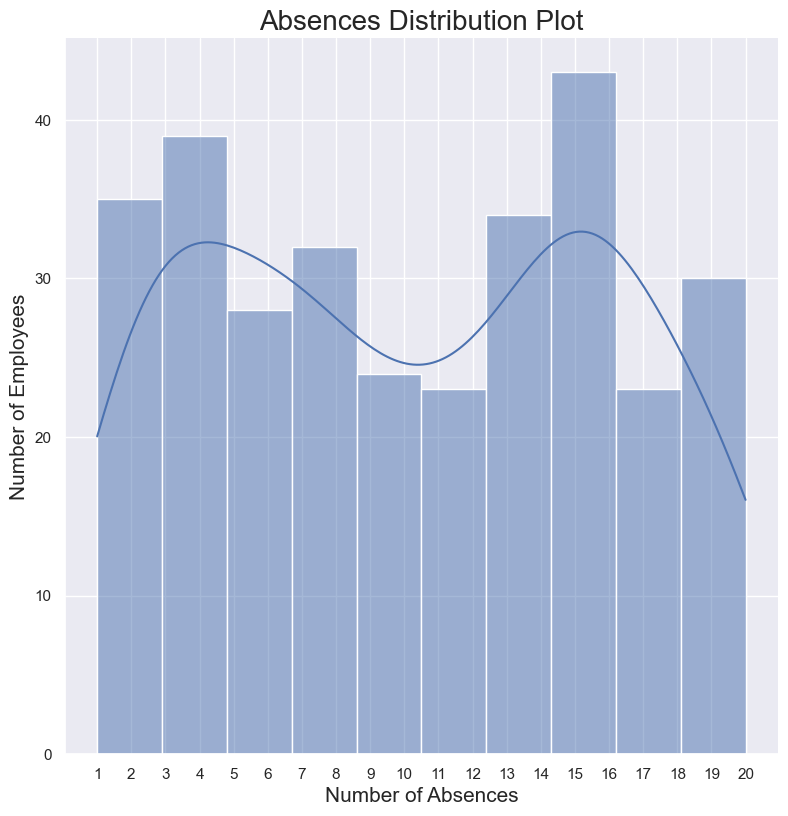

In [36]:
sns.displot(hr.Absences, height = 8, kde = True)
plt.title('Absences Distribution Plot', fontsize = 20)

xAbsencesIntervalList = [] 

for i in range(20):
    xAbsencesIntervalList.append(i+1)
    
plt.xticks(ticks = xAbsencesIntervalList)

plt.xlabel('Number of Absences', fontsize = 15)
plt.ylabel('Number of Employees', fontsize = 15)
plt.xticks(rotation = 0)
plt.show()

To create a visualization of termination reasons, we will filter for terminated employees.

In [37]:
hr_terms = hr[hr['Termd'] == 1]
hr_terms

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
10,"Baczenski, Rachael",10252,1,1,0,5,5,3,1,54670,...,David Stanley,14.0,Diversity Job Fair,Fully Meets,4.20,4,0,1/30/2016,0,12
11,"Barbara, Thomas",10242,1,1,1,5,5,3,1,47211,...,Kissy Sullivan,20.0,Diversity Job Fair,Fully Meets,4.20,3,0,5/6/2016,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,"Wilber, Barry",10048,1,1,1,5,5,3,0,55140,...,Amy Dunn,11.0,Website,Fully Meets,5.00,3,0,2/15/2015,0,7
302,"Wilkes, Annie",10204,0,2,0,5,5,3,0,58062,...,Ketsia Liebig,19.0,Google Search,Fully Meets,3.60,5,0,2/6/2011,0,9
303,"Williams, Jacquelyn",10264,0,0,0,5,5,3,1,59728,...,Ketsia Liebig,19.0,Diversity Job Fair,Fully Meets,4.30,4,0,6/2/2014,0,16
304,"Winthrop, Jordan",10033,0,0,1,5,5,4,0,70507,...,Brannon Miller,12.0,LinkedIn,Exceeds,5.00,3,0,1/19/2016,0,7


In this visualization, we see the break down of termination reasons. Most left their jobs for another position, followed by "Unhappy", "More money", "Career change", and "Hours".

Text(0.5, 1.02, 'Term Reason Bar Chart')

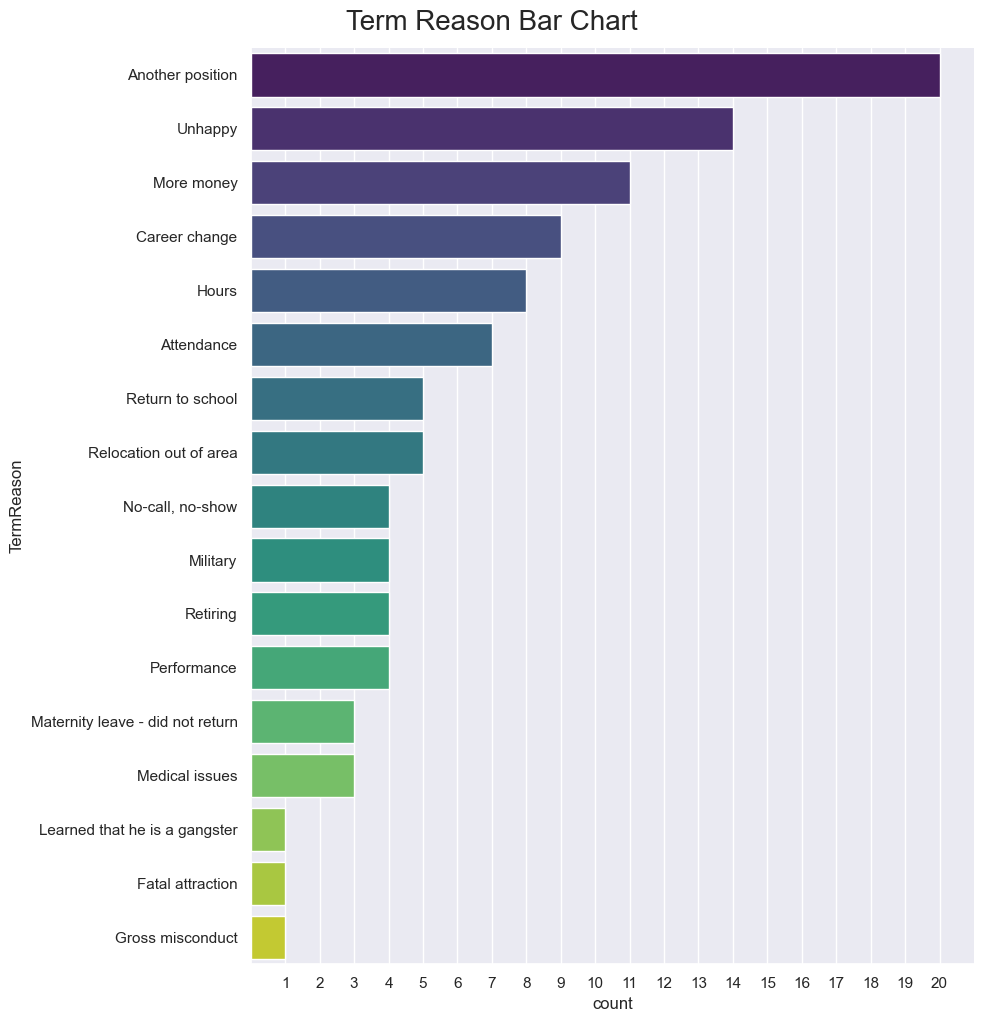

In [38]:
TermReasonViz = sns.catplot(
                            data = hr_terms, y = "TermReason", height = 10, kind = "count",
                            order = hr_terms['TermReason'].value_counts().index,
                            palette = "viridis",
                        )

xTermReasonIntervalList = [] 

for i in range(20):
    xTermReasonIntervalList.append(i+1)

plt.xticks(ticks = xTermReasonIntervalList)
TermReasonViz.fig.suptitle("Term Reason Bar Chart", fontsize = 20, y = 1.02)

## 7) Data Analysis: Employee Turnover

In this section, we will analyze the organization's turnover on a year-over-year basis.

First, we will create a copy of the data set to use in the analysis.

In [39]:
hr_copy = hr.copy()
hr_copy

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


Next, we will convert both the "DateofHire" and "DateofTermination" columns to date-time for data manipulation and analysis.

In [40]:
hr_copy['DateofHire'] = pd.to_datetime(hr_copy['DateofHire'])
hr_copy['DateofTermination'] = pd.to_datetime(hr_copy['DateofTermination'])
hr_copy

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


We now see that both columns have been converted to datetime.

In [41]:
hr_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Employee_Name               311 non-null    object        
 1   EmpID                       311 non-null    int64         
 2   MarriedID                   311 non-null    int64         
 3   MaritalStatusID             311 non-null    int64         
 4   GenderID                    311 non-null    int64         
 5   EmpStatusID                 311 non-null    int64         
 6   DeptID                      311 non-null    int64         
 7   PerfScoreID                 311 non-null    int64         
 8   FromDiversityJobFairID      311 non-null    int64         
 9   Salary                      311 non-null    int64         
 10  Termd                       311 non-null    int64         
 11  PositionID                  311 non-null    int64         

We will assign the cleaned data set to the variable "hr_turnover" for readability.

In [42]:
hr_turnover = hr_copy
hr_turnover

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


To create a visualization of the organization's turnover rate year-over-year, we will create a subset of the data set with the following columns:

**year**: Group the data set by their respective years

**terminations**: The number of terminations in each year

**cumulative_hires**: The total number of hires every year on a rolling basis

**cumulative_terminations**: The total number of terminations every year on a rolling basis

**cumulative_headcount**: The total headcount every year on a rolling basis, which is calculated by subtracting cumulative_terminations from cumulative_hires on a yearly basis

**average_headcount**: The average headcount between the start of the year and the end of the year - in this instance, the "starting headcount" used is the cumulative_headcount of the previous year,  and the "ending headcount" used is the cumulative_headcount for the current year

**turnover_rate**: The number of yearly terminations divided by the yearly average headcount, multiplied by 100 and rounded to the nearest hundredths to yield a percentage

In [43]:
hr_terminated = hr_turnover[hr_turnover["DateofTermination"].notnull()]

hr_terminated["TerminationYear"] = hr_terminated["DateofTermination"].dt.strftime('%Y')
yearly_terms = hr_terminated.groupby("TerminationYear").size().rename("terminations")

cumulative_hires = hr_turnover.groupby(hr_turnover["DateofHire"].dt.strftime('%Y')).size().rename("cumulative_hires")
yearly_cumulative_hires = cumulative_hires.cumsum()

cumulative_terms = hr_turnover.groupby(hr_turnover["DateofTermination"].dt.strftime('%Y')).size().rename("cumulative_terminations")
yearly_cumulative_terms = cumulative_terms.cumsum()

yearly_turnover_df = pd.concat([yearly_terms, yearly_cumulative_hires, yearly_cumulative_terms], axis=1).fillna(0)

yearly_turnover_df = yearly_turnover_df.sort_index()

yearly_turnover_df["cumulative_headcount"] = yearly_turnover_df["cumulative_hires"] - yearly_turnover_df["cumulative_terminations"]

yearly_turnover_df["average_headcount"] = (yearly_turnover_df["cumulative_headcount"] + yearly_turnover_df["cumulative_headcount"].shift(1))/2

yearly_turnover_df["turnover_rate"] = ((yearly_turnover_df["terminations"]/yearly_turnover_df["average_headcount"]) * 100).round(2)

yearly_turnover_df

/var/folders/21/ktnqm93s7bj09ctg2j5f2d4w0000gn/T/ipykernel_46843/3226845221.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hr_terminated["TerminationYear"] = hr_terminated["DateofTermination"].dt.strftime('%Y')


,terminations,cumulative_hires,cumulative_terminations,cumulative_headcount,average_headcount,turnover_rate
2006,0.0,1,0.0,1.0,NaN,NaN
2007,0.0,3,0.0,3.0,2.0,0.00
2008,0.0,6,0.0,6.0,4.5,0.00
2009,0.0,13,0.0,13.0,9.5,0.00
2010,1.0,22,1.0,21.0,17.0,5.88
2011,3.0,105,4.0,101.0,61.0,4.92
2012,8.0,150,12.0,138.0,119.5,6.69
2013,13.0,194,25.0,169.0,153.5,8.47
2014,13.0,254,38.0,216.0,192.5,6.75
2015,23.0,290,61.0,229.0,222.5,10.34


We will visualize the the year-over-year turnover rates using a line chart.

From 2007 - 2009, there are no terminations so the turnover rate is 0.

**The year with the highest turnover rate is 2015, with a turnover rate of 10.34%.**

**The year with the lowest turnover rate is 2017, with a turnover rate of 3.64%.**

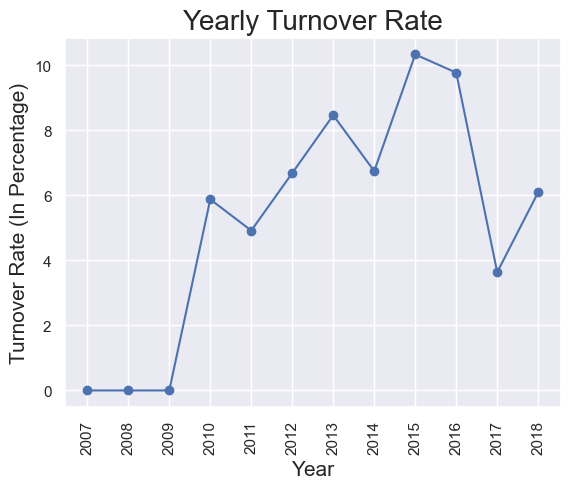

In [44]:
x = yearly_turnover_df.index
y = yearly_turnover_df["turnover_rate"]

plt.plot(x, y, marker = 'o')
plt.title('Yearly Turnover Rate', fontsize = 20)
plt.xlabel('Year', fontsize = 15)
plt.ylabel('Turnover Rate (In Percentage)', fontsize = 15)
plt.xticks(rotation = "vertical")
plt.show()

We can visualize the reasons why employees left in 2015 and 2017. First, we will create a data set of terminated employees with an added column that specifies their year of termination.

In [45]:
term_year = hr_terminated['DateofTermination'].dt.strftime('%Y')

hr_terminated["year_terminated"] = term_year
hr_terminated

/var/folders/21/ktnqm93s7bj09ctg2j5f2d4w0000gn/T/ipykernel_46843/487500036.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hr_terminated["year_terminated"] = term_year


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,TerminationYear,year_terminated
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17,2016,2016
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3,2012,2012
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2,2016,2016
10,"Baczenski, Rachael",10252,1,1,0,5,5,3,1,54670,...,Diversity Job Fair,Fully Meets,4.20,4,0,1/30/2016,0,12,2017,2017
11,"Barbara, Thomas",10242,1,1,1,5,5,3,1,47211,...,Diversity Job Fair,Fully Meets,4.20,3,0,5/6/2016,0,15,2016,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,"Wilber, Barry",10048,1,1,1,5,5,3,0,55140,...,Website,Fully Meets,5.00,3,0,2/15/2015,0,7,2015,2015
302,"Wilkes, Annie",10204,0,2,0,5,5,3,0,58062,...,Google Search,Fully Meets,3.60,5,0,2/6/2011,0,9,2012,2012
303,"Williams, Jacquelyn",10264,0,0,0,5,5,3,1,59728,...,Diversity Job Fair,Fully Meets,4.30,4,0,6/2/2014,0,16,2015,2015
304,"Winthrop, Jordan",10033,0,0,1,5,5,4,0,70507,...,LinkedIn,Exceeds,5.00,3,0,1/19/2016,0,7,2016,2016


Below is a visualization of the termination reasons for 2015. The top reasons were "Another Position" and "Unhappy".

Text(0.5, 1.02, '2015 Term Reason Bar Chart')

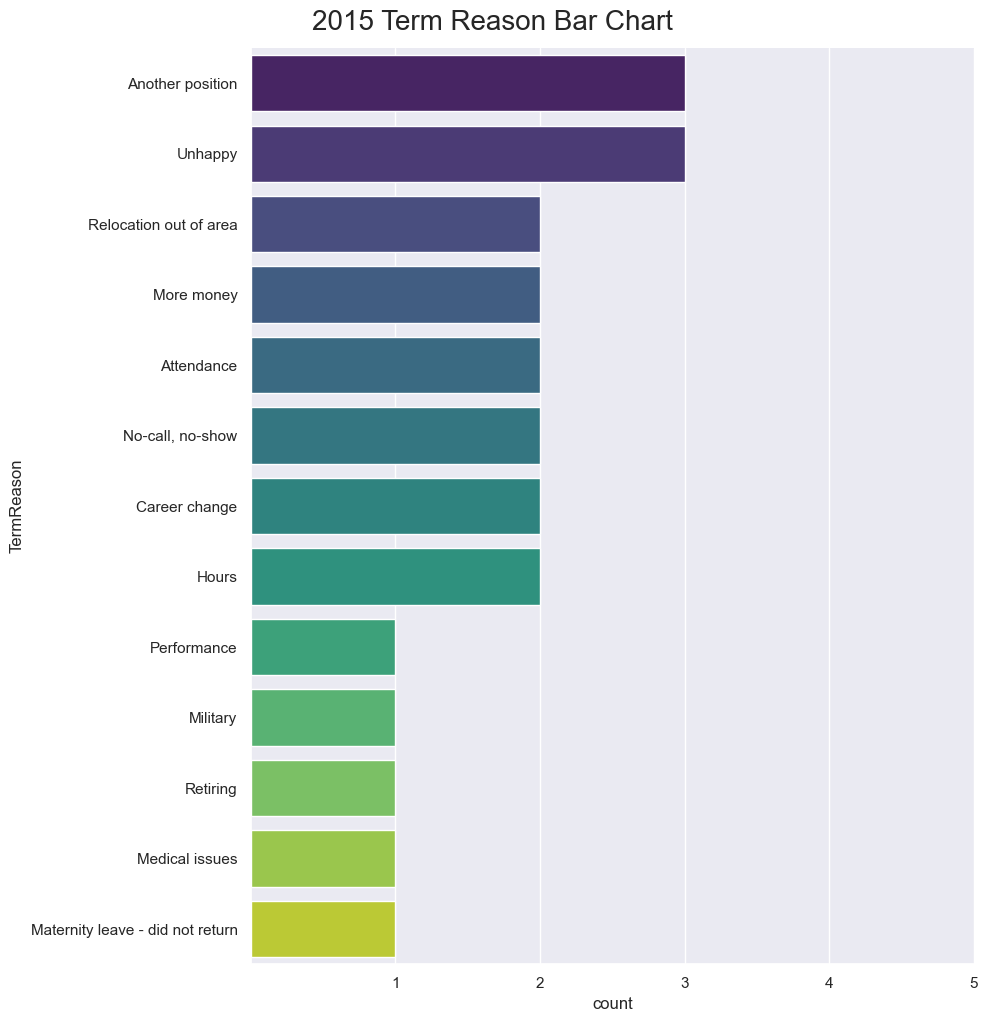

In [46]:
hr_terms2015 = hr_terminated[hr_terminated['year_terminated'] == '2015']

TermReasonViz = sns.catplot(
                            data = hr_terms2015, y = "TermReason", height = 10, kind = "count",
                            order = hr_terms2015['TermReason'].value_counts().index,
                            palette = "viridis",
                        )

xTermReasonIntervalList = [] 

for i in range(5):
    xTermReasonIntervalList.append(i+1)

plt.xticks(ticks = xTermReasonIntervalList)
TermReasonViz.fig.suptitle("2015 Term Reason Bar Chart", fontsize = 20, y = 1.02)

Below is a visualization of the termination reasons for 2017. The top reason was "Another Position".

Text(0.5, 1.02, '2017 Term Reason Bar Chart')

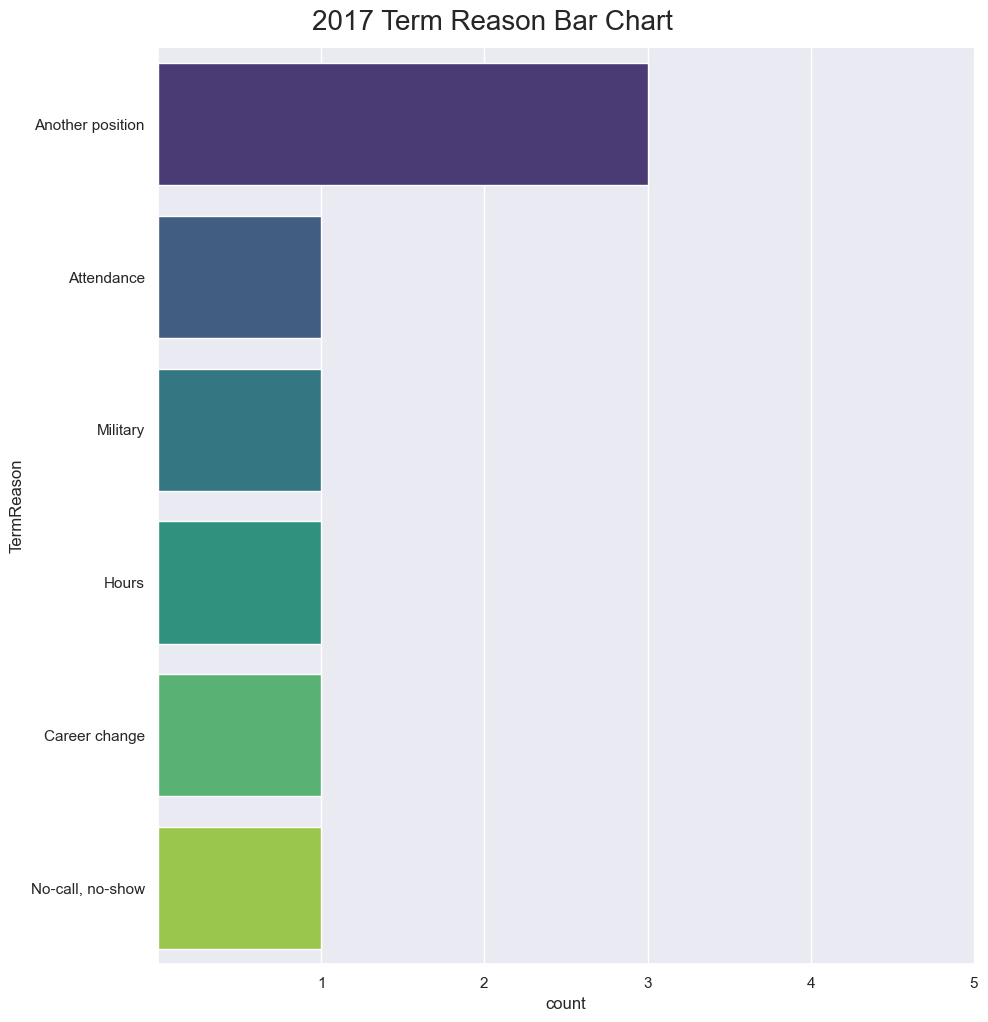

In [47]:
hr_terms2017 = hr_terminated[hr_terminated['year_terminated'] == '2017']

TermReasonViz = sns.catplot(
                            data = hr_terms2017, y = "TermReason", height = 10, kind = "count",
                            order = hr_terms2017['TermReason'].value_counts().index,
                            palette = "viridis",
                        )

xTermReasonIntervalList = [] 

for i in range(5):
    xTermReasonIntervalList.append(i+1)

plt.xticks(ticks = xTermReasonIntervalList)
TermReasonViz.fig.suptitle("2017 Term Reason Bar Chart", fontsize = 20, y = 1.02)

## 8) Data Analysis: Performance Data Correlations

In this section, we will look at the correletations between employment status (active vs. terminated) and performance-based data.

First, we will create a copy of the data set to use in the analysis.

In [48]:
hr_correlations = hr.copy()
hr_correlations

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


Next, we will create a subset fo the data set based on the Employment Status (in this instance, using "Termd" - 0 for active, 1 for terminated), Engagement Survey scores, Employee Satisfaction scores, Special Projects Count, Days Late, and Absences.

In [49]:
hr_correlations_data = hr_correlations[['Termd', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences']]
hr_correlations_data

,Termd,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
0,0,4.60,5,0,0,1
1,1,4.96,3,6,0,17
2,1,3.02,3,0,0,3
3,0,4.84,5,0,0,15
4,1,5.00,4,0,0,2
...,...,...,...,...,...,...
306,0,4.07,4,0,0,13
307,1,3.20,2,0,5,4
308,0,4.60,5,6,0,16
309,0,5.00,3,5,0,11


Finally, we will generate a correlation heat map using the filtered data set above. In the visualization below, there are not many strong correlations between an employee's employment status and the selected performance-based data. However, we do see that there is a -0.59 correlation between employees' engagement survey results and the number of days they are late. The negative correlation implies that the more days employees have been late, the lower their engagement, and vice-versa.

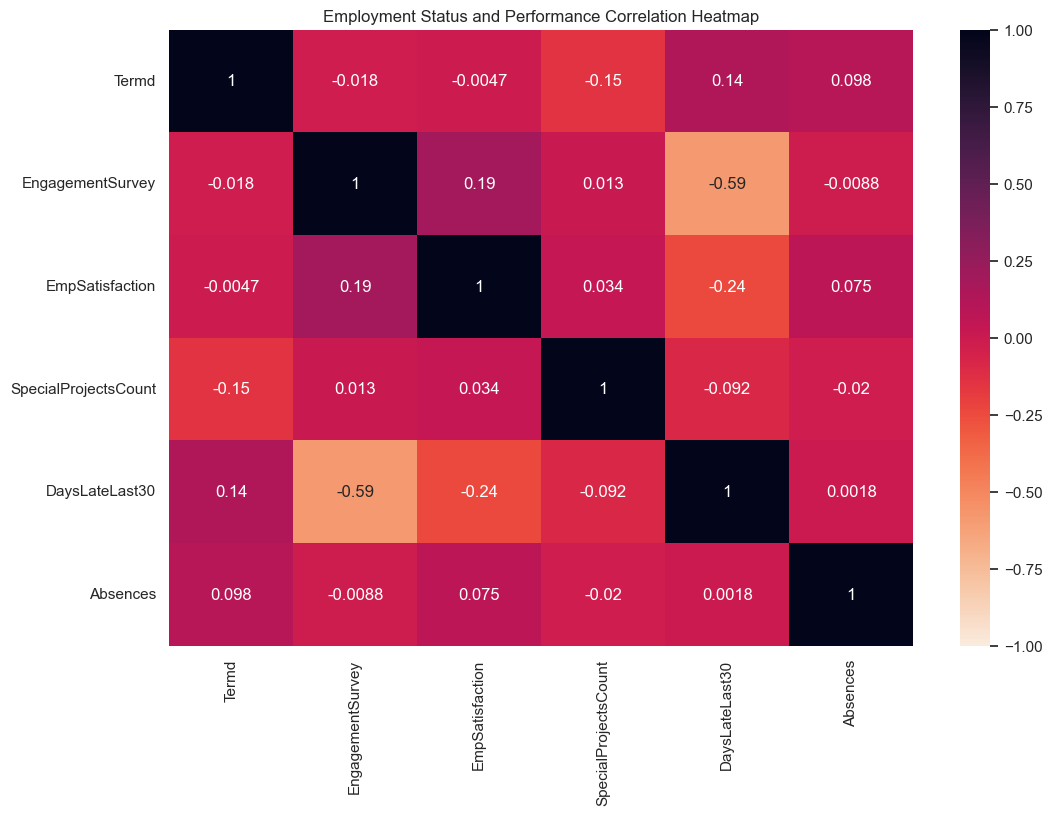

In [50]:
plt.figure(figsize = (12, 8))
heatmap = sns.heatmap(hr_correlations_data.corr(), vmin = -1, vmax = 1, annot = True, cmap = 'rocket_r')
heatmap.set_title('Employment Status and Performance Correlation Heatmap')
plt.show()

## 9) Data Analysis: Predicting Terminations

In this section, we will attempt to create a logistic regression function that we can use to predict the likelihood of whether an employee will terminate based on performance-based data.

We will do this by first splitting the data set:

1) One data set will consist of the "training" data (the majority of the initial data set), which will be used to create the logistic regression function.

2) The other data set will be a subset of the initial data set, the "test" data, which will be used to calculate the accuracy of the logistic regression function we create.

First, we will create a copy of the HR correletions data set used in the previous section. We will use this as the core data set to perform our logistic regression analysis.

In [51]:
hr_termpredictions = hr_correlations_data
hr_termpredictions

,Termd,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
0,0,4.60,5,0,0,1
1,1,4.96,3,6,0,17
2,1,3.02,3,0,0,3
3,0,4.84,5,0,0,15
4,1,5.00,4,0,0,2
...,...,...,...,...,...,...
306,0,4.07,4,0,0,13
307,1,3.20,2,0,5,4
308,0,4.60,5,6,0,16
309,0,5.00,3,5,0,11


We will create the "training" data set by obtaining the top 290 rows of the data set.

In [52]:
hr_termpredictions_train = hr_termpredictions.head(290)
hr_termpredictions_train

,Termd,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
0,0,4.60,5,0,0,1
1,1,4.96,3,6,0,17
2,1,3.02,3,0,0,3
3,0,4.84,5,0,0,15
4,1,5.00,4,0,0,2
...,...,...,...,...,...,...
285,1,4.60,3,4,0,9
286,1,4.40,3,0,0,5
287,0,5.00,4,7,0,8
288,0,2.81,3,0,0,16


We will then create the "test" data set by obtaining the last 21 rows of the data set.

In [53]:
hr_termpredictions_test = hr_termpredictions.tail(21)
hr_termpredictions_test

,Termd,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
290,0,3.93,3,0,0,19
291,0,4.50,4,0,0,11
292,1,4.33,3,7,0,9
293,1,4.30,5,0,0,18
294,0,3.21,3,0,0,7
295,0,3.11,5,0,0,4
296,1,4.50,3,0,0,5
297,1,2.50,3,0,6,13
298,0,3.42,4,7,0,17
299,0,4.20,4,8,0,7


Next, we need to create the dependent and independent variables. 

In our analyses, the "Termd" column will be our dependent variable - the variable we are trying to predict. The "Termd" column consists of 0s and 1s: 0 for active and 1 for terminated.

The independent variables will be all of the other fields in our data set. These are the inputs we will be using in our function to predict whether an employee will stay active (0) or terminate (1). The independent variables will be the numerical values of our performance-based data: Engagement Survey results, Employee Satisfaction, Special Projects Count, Days Late, and Absences.

In [54]:
# Dependent Variable

y = hr_termpredictions_train['Termd']


# We will create a dataframe "x0" that will contain all of the independent variables aggregated as an array

x0 = hr_termpredictions_train[['EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences']]

We will now produce the logistic regression table that will provide us with the coefficients needed for our logistic regression function.

Based on the results below, our logit model will be:

log(odds) = -1.9775 + 0.1406 * EngagementSurvey + 0.0762 * EmpSatisfaction + -0.1335 * SpecialProjectsCount + 0.2270 * DaysLateLast30 + 0.0389 * Absences


To get the odds of an employee terminating based on their performance-based data , we would take the exponential of each side, which yields:

**odds of employee terminating = e^(-1.9775 + 0.1406 * EngagementSurvey + 0.0762 * EmpSatisfaction + -0.1335 * SpecialProjectsCount + 0.2270 * DaysLateLast30 + 0.0389 * Absences)**

In [55]:
x = sm.add_constant(x0)
RegLog = sm.Logit(y,x)
ResultsLog = RegLog.fit()
ResultsLog.summary()

Optimization terminated successfully.
         Current function value: 0.607440
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Termd   No. Observations:                  290
Model:                          Logit   Df Residuals:                      284
Method:                           MLE   Df Model:                            5
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                 0.03573
Time:                        17:22:16   Log-Likelihood:                -176.16
converged:                       True   LL-Null:                       -182.69
Covariance Type:            nonrobust   LLR p-value:                   0.02287
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -1.9775      1.034     -1.913      0.056      -4.004       0.049
EngagementSurvey         0.1406      0.202      0.697      0.486      -0.255       0.536
EmpSatisfaction          0.0762      0.145      0.525      0.600      -0.208       0.361
SpecialProjectsCount    -0.1335      0.063     -2.111      0.035      -0.257      -0.010
DaysLateLast30           0.2270      0.123      1.852      0.064      -0.013       0.467
Absences                 0.0389      0.022      1.775      0.076      -0.004       0.082
========================================================================================
"""

We can view the outputs of the logistic regression function based on the inputs provided. In the array below, we can see the output values (from 0 - 1), which represents the probability of an employee being active or terminated based on the training data. For example, a result of 0.29 means there is a 29% chance that the employee is a terminated employee.

In [56]:
np.set_printoptions(formatter = {'float': lambda x: "{0:0.2f}".format(x)}, threshold = np.inf)
ResultsLog.predict()

array([0.29, 0.23, 0.23, 0.42, 0.29, 0.42, 0.25, 0.44, 0.28, 0.25, 0.35,
       0.36, 0.20, 0.32, 0.30, 0.45, 0.38, 0.39, 0.20, 0.36, 0.37, 0.25,
       0.42, 0.29, 0.33, 0.12, 0.23, 0.33, 0.28, 0.19, 0.28, 0.39, 0.45,
       0.28, 0.36, 0.15, 0.38, 0.16, 0.36, 0.19, 0.35, 0.37, 0.17, 0.31,
       0.29, 0.37, 0.28, 0.27, 0.14, 0.34, 0.30, 0.29, 0.30, 0.57, 0.39,
       0.38, 0.33, 0.11, 0.39, 0.20, 0.33, 0.18, 0.27, 0.29, 0.28, 0.40,
       0.19, 0.52, 0.29, 0.40, 0.18, 0.26, 0.39, 0.29, 0.37, 0.22, 0.18,
       0.41, 0.29, 0.25, 0.32, 0.35, 0.26, 0.30, 0.69, 0.61, 0.45, 0.42,
       0.30, 0.33, 0.64, 0.16, 0.46, 0.46, 0.27, 0.47, 0.27, 0.23, 0.40,
       0.16, 0.28, 0.35, 0.38, 0.27, 0.30, 0.54, 0.27, 0.45, 0.24, 0.24,
       0.33, 0.27, 0.44, 0.22, 0.42, 0.28, 0.28, 0.29, 0.26, 0.44, 0.20,
       0.45, 0.36, 0.43, 0.33, 0.31, 0.26, 0.39, 0.32, 0.37, 0.17, 0.43,
       0.17, 0.30, 0.27, 0.29, 0.37, 0.34, 0.34, 0.29, 0.33, 0.35, 0.37,
       0.34, 0.14, 0.25, 0.28, 0.29, 0.30, 0.38, 0.

We can confirm that the number of outputs in the prediction array above matches the number of inputs in the training data, which is 290.

In [57]:
len(ResultsLog.predict())

290

We will then confirm the accuracy of our logistic regression model.

We will use the prediction outputs array of the training data and compare it with the actual outputs (between 0 and 1).

We can see the array of the actual Termd values below.

In [58]:
np.array(hr_termpredictions_train['Termd'])

array([0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1])

We can confirm that the the number of values within the training data of the 'Termd'column is 290.

In [59]:
len(np.array(hr_termpredictions_train['Termd']))

290

We will then create a Confusion Matrix or a Prediction Table. This is essentially a table that shows how accurate our logistic regression model is based on how many of its predictions were correct and how many were incorrect.

**IMPORTANT: In the prediction table below, values within the prediction array that are less than 0.5 are rounded down to 0 and values equal to or greater than 0.5 are rounded up to 1.**

In [60]:
ResultsLog.pred_table()

array([[192.00, 4.00],
       [87.00, 7.00]])

For readability, we will format the Prediction Table. It can be interpreted as follows:

1) There are 192 values that were predicted to have a value of 0 and actually had a value of 0. 
**This means that 192 employees predicted to be active were actually active.**

2) There are 87 values that were predicted to have a value of 0 but actually had a value of 1. 
**This means that 87 employees predicted to be active were actually terminated.**

3) There are 4 values that were predicted to have a value of 1 but actually had a value of 0. 
**This means that 4 employees predicted to be terminated were actually active.**

4) There are 7 values that were predicted to have a value of 1 and actually had a value of 1. 
**This means that 7 employees predicted to be terminated were actually terminated.**

In [61]:
ptDF = pd.DataFrame(ResultsLog.pred_table())
ptDF.columns = ['Predicted 0', 'Predicted 1']
ptDF = ptDF.rename(index = {0: 'Actual 0', 1:'Actual 1'})
ptDF

,Predicted 0,Predicted 1
Actual 0,192.0,4.0
Actual 1,87.0,7.0


Based on the Prediction Table above, we can calculate the accuracy rate of the model based on the training data. The accuracy rate is 68.62%.

In [62]:
pt = np.array(ptDF)
accuracy = (pt[0,0] + pt[1,1])/pt.sum()
print("Accuracy Rate: {}%".format(round((accuracy*100),2)))

Accuracy Rate: 68.62%


In turn, we can calculate the misclassification rate of the model based on the training data. The misclassification rate is 31.38%.

In [63]:
mr = (pt[0,1] + pt[1,0])/pt.sum()
mr
print("Misclassification Rate: {}%".format(round((mr*100),2)))

Misclassification Rate: 31.38%


Next, we will use the test data to calculate how accurate our model is outside of the data we used to create (or "train") it.

We can first take a look at the test data and its values from the "Termd" column.

In [64]:
test_actual = hr_termpredictions_test['Termd']
test_actual

290    0
291    0
292    1
293    1
294    0
295    0
296    1
297    1
298    0
299    0
300    1
301    1
302    1
303    1
304    1
305    0
306    0
307    1
308    0
309    0
310    0
Name: Termd, dtype: int64

To use the test_data as a parameter for the logistic regression function, we will drop the "Termd" column and add a constant column, consisting of the number 1. This is a placeholder as the logistic regression function consists of a constant.

In [65]:
test_data = hr_termpredictions_test.drop(['Termd'],axis=1)
test_data = sm.add_constant(test_data)
test_data

,const,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
290,1.0,3.93,3,0,0,19
291,1.0,4.50,4,0,0,11
292,1.0,4.33,3,7,0,9
293,1.0,4.30,5,0,0,18
294,1.0,3.21,3,0,0,7
295,1.0,3.11,5,0,0,4
296,1.0,4.50,3,0,0,5
297,1.0,2.50,3,0,6,13
298,1.0,3.42,4,7,0,17
299,1.0,4.20,4,8,0,7


Next, we will create a confusion matrix function that will provide a Prediction Table and Accuracy Rate as outputs. The confusion matrix function will take the following inputs: Test Data, Test Actual (actual results of the test data), and the Model (in this case, the logistic regression model).

In [66]:
def confusion_matrix(data,actual_values,model):
        
        # Confusion matrix 
        
        # Parameters
        # ----------
        # data: data frame or array
            # data is a data frame formatted in the same way as input data (without the actual values)
            # e.g. const, var1, var2, etc. Order is important.
        # actual_values: data frame or array
            # These are the actual values from the test_data
            # In the case of a logistic regression, it should be a single column with 0s and 1s
            
        # model: a LogitResults object
            # this is the variable where you have the fitted model 
            # e.g. ResultsLog in this analysis
        # ----------
        
        #Predict the values using the Logit model
        pred_values = model.predict(data)
        
        # Specify the bins 
        bins = np.array([0,0.5,1])
        
        # Create a histogram, where if values are between 0 and 0.5 tell will be considered 0
        # if they are between 0.5 and 1, they will be considered 1
        cm = np.histogram2d(actual_values, pred_values, bins=bins)[0]
        
        # Calculate the accuracy
        accuracy = (cm[0,0]+cm[1,1])/cm.sum()
        
        # Return the confusion matrix and the accuracy
        return cm, accuracy

We will now use the Confusion Matrix function with the required inputs.

In [67]:
cm = confusion_matrix(test_data,test_actual,ResultsLog)
cm

(array([[11.00, 0.00],
        [9.00, 1.00]]),
 0.5714285714285714)

For readability, we will format the Confusion Matrix output (the Prediction Table) for our test data.

It can be interpreted as follows:

1) There are 11 values that were predicted to have a value of 0 and actually had a value of 0. 
**This means that 11 employees predicted to be active were actually active.**

2) There are 9 values that were predicted to have a value of 0 but actually had a value of 1. 
**This means that 9 employees predicted to be active were actually terminated.**

3) There are 0 values that were predicted to have a value of 1 but actually had a value of 0. 
**This means that 0 employees predicted to be terminated were actually active.**

4) There are 7 values that were predicted to have a value of 1 and actually had a value of 1. 
**This means that 1 employee predicted to be terminated was actually terminated.**

In [68]:
cm_test = pd.DataFrame(cm[0])
cm_test.columns = ['Predicted 0','Predicted 1']
cm_test = cm_test.rename(index={0: 'Actual 0',1:'Actual 1'})
cm_test

,Predicted 0,Predicted 1
Actual 0,11.0,0.0
Actual 1,9.0,1.0


Based on the Prediction Table above, we can calculate the accuracy rate of the model based on the test data. The accuracy rate is 57.14%.

In [69]:
pt_test = np.array(cm_test)
pt_test_accuracy = (pt_test[0,0] + pt_test[1,1])/pt_test.sum()
print("Accuracy Rate: {}%".format(round((pt_test_accuracy*100),2)))

Accuracy Rate: 57.14%


In turn, we can calculate the misclassification rate of the model based on the test data. The misclassification rate is 42.86%.

In [70]:
mr_test = (pt_test[0,1] + pt_test[1,0])/pt_test.sum()
mr_test
print("Misclassification Rate: {}%".format(round((mr_test*100),2)))

Misclassification Rate: 42.86%


## 10) Conclusion

Based on the analyses we conducted, below are the key takeaways:

#### Summary Statistics

- Of the 311 employees in the data set, 207 are active and 104 are terminated.

- Most employees are located in Massachusetts.

- Indeed, LinkedIn, and Google Search are the top recruitment sources.

- Most employees are under the Production department.

- The top five positions in terms of headcount are: Production Technician I, Production Technician II, Area Sales Manager, Production Manager, and Software Engineer.

- Most employees fall under the $70-75k salary range.

- In terms of performance, most employees fall under Fully Meets.

- Diving deeper into performance data, observe the following:

    - Engagement Survey scores (from 1 - 5) have an average score is 4.11 with a standard deviation of 0.79.
    - Employee Satisfaction scores (from 1 - 5) have an average score of 3.89 with a standard deviation of 0.90.
    - Special Projects count have an average of 1.21 with a standard deviation of 2.39.
    - Days Late count have an average of average 0.41 with a standard deviation of 1.29.
    - Absences have an average of 10.23 days with a standard deviation of 5.85.
    
- The top termination reasons in order are the following: "Another position", "Unhappy", "More money", "Career change", and "Hours".

#### Employee Turnover

In our employee turnover analysis, we found that:

- 2015 had the highest turnover rate with 10.34%. The top termination reasons for this year are "Another position" and "Unhappy". 

- 2017 had the lowest turnover rate with 3.64%. The top termination reason for this year is "Another position".

#### Performance Data Correlations

In our performance data correlations analysis, we found that there are no correlations between an employee terminating and their performance data. The highest correlation found was between employees' engagement survey results and the number of days they are late. The correlation of -0.59 implies that the more days employees have been late, the lower their engagement, and vice-versa.

#### Employee Termination Predictions

In attempting to create a function that will allow us to predict an employee's likelihood to terminate, we used a logistic regression analysis with the following performance parameters:

- Engagement Survey Scores
- Employee Satisfcation Scores
- Special Projects Count
- Days Late
- Absences 

The analysis yielded the following function:

odds of employee terminating = e^(-1.9775 + 0.1406 * EngagementSurvey + 0.0762 * EmpSatisfaction + -0.1335 * SpecialProjectsCount + 0.2270 * DaysLateLast30 + 0.0389 * Absences)

Based on the training data we used to create this function, this function's accuracy rates are the following:

- Accuracy rate: 68.62%
- Misclassification rate: 31.38%


Based on the test data we used to understand how well the function predicted terminations outside of the training data it used, below are the accuracy rates it yielded:

- Accuracy rate: 57.14%
- Misclassification rate: 42.86%


The function using the training data can correctly predict whether an employee will terminate 68.62% of the time. However, when the function is tested using data outside of the training data, this accuracy rate drops to 57.14%. The function itself can predict a termination successfully only a little over half the time, based on the performance data parameters. This makes sense given how the individual performance parameters did not have strong correlations with an employee's termination status.